In [1]:
from keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D

In [2]:
(x_img_train ,y_label_train), (x_img_test ,y_label_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
print("Train Data:" ,x_img_train.shape ,y_label_train.shape)
print("Test Data:" ,x_img_test.shape ,y_label_test.shape)

Train Data: (50000, 32, 32, 3) (50000, 1)
Test Data: (10000, 32, 32, 3) (10000, 1)


In [4]:
label_dict = {0:"airplane" ,1:"automobile" ,2:"bird" ,3:"cat" ,
        4:"deer" ,5:"dog" ,6:"frog" ,7:"horse" ,8:"ship" ,
        9:"truck"}

In [5]:
x_img_train_normalize = x_img_train.astype("float32") / 255.0
x_img_test_normalize = x_img_test.astype("float32") / 255.0

In [6]:
y_label_train_OneHot = to_categorical(y_label_train)
y_label_test_OneHot = to_categorical(y_label_test)

In [7]:
y_label_train_OneHot.shape
y_label_test_OneHot.shape

(10000, 10)

In [8]:
model = Sequential()

In [9]:
model.add(Conv2D(filters=32,
         kernel_size=(3 ,3),
         input_shape=(32, 32 ,3),
         activation='relu',
         padding="same"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.add( MaxPooling2D(pool_size=(2 ,2)) )

In [11]:
model.add( Flatten() )

In [12]:
model.add( Dense(1024 ,activation="relu") )

In [13]:
model.add( Dense(10 ,activation="softmax") )

In [14]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,400,778 (32.05 MB)

 Trainable params: 8,400,778 (32.05 MB)

 Non-trainable params: 0 (0.00 B)

None


In [15]:
model.compile(loss="categorical_crossentropy",
       optimizer="adam",
       metrics=["accuracy"])

In [16]:
train_history = model.fit(x_img_train_normalize,
               y_label_train_OneHot,
               validation_split=0.2,
               epochs=10,
               batch_size=128,
               verbose=0)

In [18]:
scores = model.evaluate(x_img_test_normalize,
              y_label_test_OneHot,
              batch_size=1)
scores[1]

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.6627 - loss: 1.1603


0.6626999974250793

In [19]:
pre = model.predict( x_img_test_normalize ,batch_size=1 )
prediction = np.argmax( pre ,axis=1)
prediction

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


array([3, 8, 0, ..., 5, 4, 7])

In [20]:
prediction[:10]

array([3, 8, 0, 0, 4, 6, 1, 6, 3, 1])

In [21]:
y_label_test[:10]

array([[3],
       [8],
       [8],
       [0],
       [6],
       [6],
       [1],
       [6],
       [3],
       [1]], dtype=uint8)

In [22]:
def show(x_img=x_img_test, y_label=y_label_test ,prediction=prediction ,i=98) -> None:
  print("Label:" ,label_dict[y_label[i][0]],
     "Predict:" ,label_dict[prediction[i]])
  plt.figure(figsize=(2 ,2))
  plt.imshow(x_img[i])
  plt.show()

Label: airplane Predict: bird


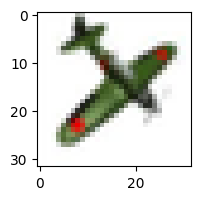

In [23]:
show(i=98)